<a href="https://colab.research.google.com/github/ajayioisaac/Data_Science_Repo/blob/main/Deep_Neural_Network_Checkpoint.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pandas numpy seaborn matplotlib scikit-learn keras

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from keras.models import Sequential
from keras.layers import Dense, Dropout
from sklearn.metrics import classification_report, confusion_matrix


In [3]:
df = pd.read_csv("bank.csv")  # Replace with your actual path
print(df.head())
print(df.info())
print(df['deposit'].value_counts())


   age         job  marital  education default  balance housing loan  contact  \
0   59      admin.  married  secondary      no     2343     yes   no  unknown   
1   56      admin.  married  secondary      no       45      no   no  unknown   
2   41  technician  married  secondary      no     1270     yes   no  unknown   
3   55    services  married  secondary      no     2476     yes   no  unknown   
4   54      admin.  married   tertiary      no      184      no   no  unknown   

   day month  duration  campaign  pdays  previous poutcome deposit  
0    5   may      1042         1     -1         0  unknown     yes  
1    5   may      1467         1     -1         0  unknown     yes  
2    5   may      1389         1     -1         0  unknown     yes  
3    5   may       579         1     -1         0  unknown     yes  
4    5   may       673         2     -1         0  unknown     yes  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 

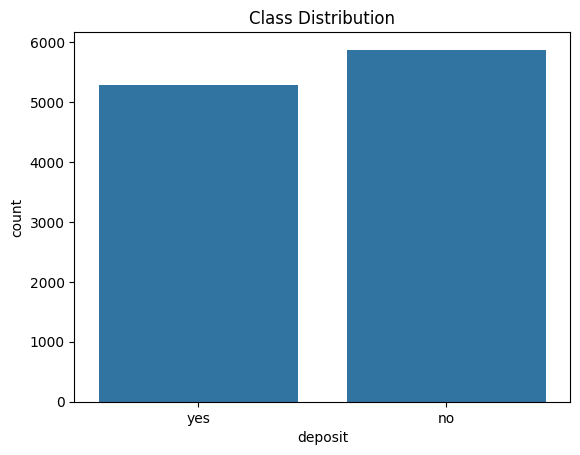

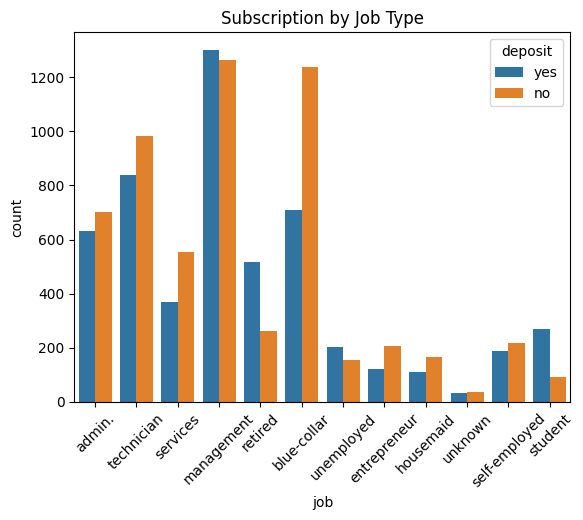

In [4]:
sns.countplot(x='deposit', data=df)
plt.title('Class Distribution')
plt.show()

sns.countplot(x='job', data=df, hue='deposit')
plt.xticks(rotation=45)
plt.title('Subscription by Job Type')
plt.show()


In [5]:
# Encode target
df['deposit'] = df['deposit'].map({'yes': 1, 'no': 0})

# Encode categorical features
categorical = df.select_dtypes(include='object').columns
df = pd.get_dummies(df, columns=categorical, drop_first=True)

# Feature/target split
X = df.drop('deposit', axis=1)
y = df['deposit']

# Scale numerical data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


In [6]:
model = Sequential()
model.add(Dense(64, input_dim=X_train.shape[1], activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(1, activation='sigmoid'))  # Binary classification

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.fit(X_train, y_train, validation_split=0.2, epochs=30, batch_size=32, verbose=1)


Epoch 1/30


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


224/224 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6315 - loss: 0.6375 - val_accuracy: 0.8119 - val_loss: 0.4391
Epoch 2/30
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7929 - loss: 0.4546 - val_accuracy: 0.8303 - val_loss: 0.3967
Epoch 3/30
224/224 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8101 - loss: 0.4244 - val_accuracy: 0.8354 - val_loss: 0.3825
Epoch 4/30
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8264 - loss: 0.4026 - val_accuracy: 0.8410 - val_loss: 0.3762
Epoch 5/30
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8490 - loss: 0.3853 - val_accuracy: 0.8376 - val_loss: 0.3722
Epoch 6/30
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8417 - loss: 0.3742 - val_accuracy: 0.8404 - val_loss: 0.3705
Epoch 7/30
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8438 - loss: 0.3722 - val_accuracy: 0.8421 - val_loss: 0.3670
Epoch 8/30
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8511 - loss: 0.3524 - val_accuracy: 0.8421 - val_

In [7]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)

y_pred = (model.predict(X_test) > 0.5).astype("int32")
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8300 - loss: 0.4021
Test Accuracy: 0.8428123593330383
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
              precision    recall  f1-score   support

           0       0.89      0.80      0.84      1166
           1       0.80      0.89      0.84      1067

    accuracy                           0.84      2233
   macro avg       0.84      0.84      0.84      2233
weighted avg       0.85      0.84      0.84      2233

[[936 230]
 [121 946]]
